# M2A10 - Modelos Pré-Treinados

> **Resumo:** Chegamos ao ápice do Módulo 2! Aqui usamos um modelo de deep learning (VGG16) já treinado na ImageNet pra classificar imagens. A ideia é reaproveitar o conhecimento que o modelo já aprendeu — isso se chama **Transfer Learning**.

> 📝 **Por que pré-treinados?** Treinar uma CNN do zero exige MUITOS dados + GPU + tempo. Com pré-treinados, pegamos atalho!

**Estrutura do notebook:**

- Setup (upload + imports)
- Modelos Pré-Treinados (VGG16)
- Próximos passos
- ✅ Atividades Complementares (resolvidas)

## Importações

No Colab, PyTorch e torchvision já vêm instalados! 🎉

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cpu
CUDA disponível: False


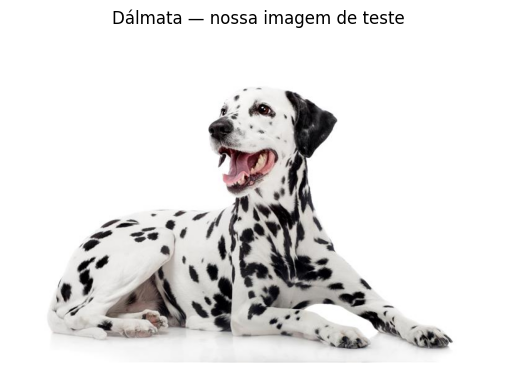

In [2]:
image = cv2.imread("/content/dog.jpeg")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Dálmata — nossa imagem de teste")
plt.axis("off")
plt.show()

## Modelos Pré-Treinados

### Carregando o VGG16

O **VGG16** foi criado pelo Visual Geometry Group da Universidade de Oxford. Tem 16 camadas e foi treinado na ImageNet (1.3 milhão de imagens, 1000 classes).

Os pesos são baixados automaticamente pelo torchvision:

In [3]:
# Definindo os pesos pré-treinados
weights = torchvision.models.VGG16_Weights.DEFAULT

# Labels das 1000 classes da ImageNet
imagenet_labels = weights.meta["categories"]

# Carregando o modelo com pesos pré-treinados
vgg_16_model = torchvision.models.vgg16(weights=weights)

# Pipeline de pré-processamento (mesmo que foi usado no treino)
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print(f"Modelo carregado! Classes disponíveis: {len(imagenet_labels)}")

Modelo carregado! Classes disponíveis: 1000


> 📝 **Pré-processamento:** O modelo espera imagens em um formato específico — 224×224, normalizadas com média e desvio padrão da ImageNet. Se não fizermos isso, os resultados ficam lixo.

### Rodando a inferência

In [4]:
# Modo de avaliação (desliga dropout, batch normalization, etc.)
vgg_16_model.eval()

# Pré-processando a imagem
image_tensor = preprocess(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
input_batch = image_tensor.unsqueeze(0)  # Adiciona dimensão do batch

print(f"Shape do tensor: {image_tensor.shape}")
print(f"Shape com batch: {input_batch.shape}")

Shape do tensor: torch.Size([3, 224, 224])
Shape com batch: torch.Size([1, 3, 224, 224])


In [5]:
# Escolhendo dispositivo (GPU se disponível no Colab!)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
input_batch = input_batch.to(device)
vgg_16_model = vgg_16_model.to(device)
print(f"Rodando em: {device}")

# Inferência
with torch.no_grad():
    output = vgg_16_model(input_batch)

# Probabilidades via softmax
probabilities = torch.nn.functional.softmax(output[0], dim=0)

Rodando em: cpu


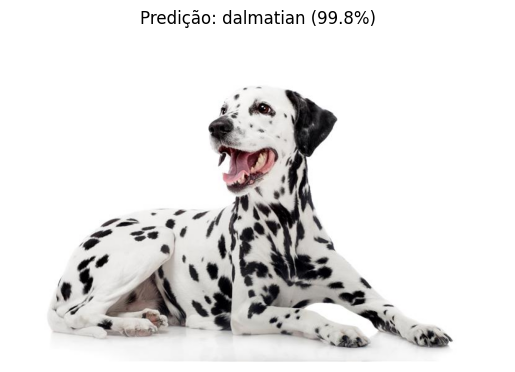

Predição do Dálmata com VGG16: dalmatian (Confiança: 99.81%)


In [6]:
# Classe predita
pred_class = imagenet_labels[torch.argmax(probabilities)]
pred_prob = probabilities[torch.argmax(probabilities)].item()

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title(f"Predição: {pred_class} ({pred_prob*100:.1f}%)")
plt.axis("off")
plt.show()

print(f"Predição do Dálmata com VGG16: {pred_class} (Confiança: {pred_prob*100:.2f}%)")

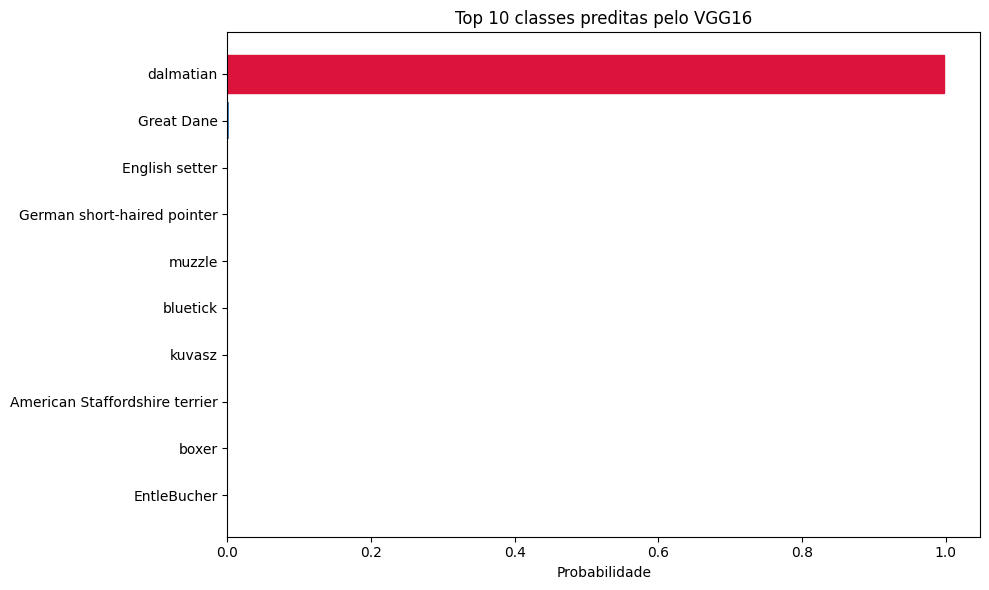

Top 5 classes mais prováveis (Dálmata - VGG16):
  - dalmatian: 99.81%
  - Great Dane: 0.17%
  - English setter: 0.01%
  - German short-haired pointer: 0.01%
  - muzzle: 0.00%


In [7]:
# Top 10 classes mais prováveis
set_labels_probs = list(zip(imagenet_labels, probabilities.cpu().numpy()))
set_labels_probs = sorted(set_labels_probs, key=lambda x: x[1])

num = 10
most_probable = set_labels_probs[-num:]
labels, probs = zip(*most_probable)

plt.figure(figsize=(10, 6))
bars = plt.barh(labels, probs, color='steelblue')
bars[-1].set_color('crimson')  # Destacar a classe mais provável
plt.xlabel("Probabilidade")
plt.title("Top 10 classes preditas pelo VGG16")
plt.tight_layout()
plt.show()

print("Top 5 classes mais prováveis (Dálmata - VGG16):")
for label, prob in reversed(list(zip(labels, probs))[-5:]):
    print(f"  - {label}: {prob*100:.2f}%")

> 📝 **Acertou!** O modelo classifica corretamente como "Dalmatian". As outras classes no top 10 são todas de raças de cachorro — faz sentido, porque visualmente um dálmata pode ser confundido com outras raças manchadas.

## Próximos Passos e Referências

Isso conclui o Módulo 2! No Módulo 3, vamos aprofundar em Transfer Learning — ou seja, pegar esses modelos e **adaptar** pra tarefas novas.

**Referências:**

- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/

## ✅ Atividades Complementares

### 1. Inferência com o Sonic — o que o VGG16 acha que ele é? 😂

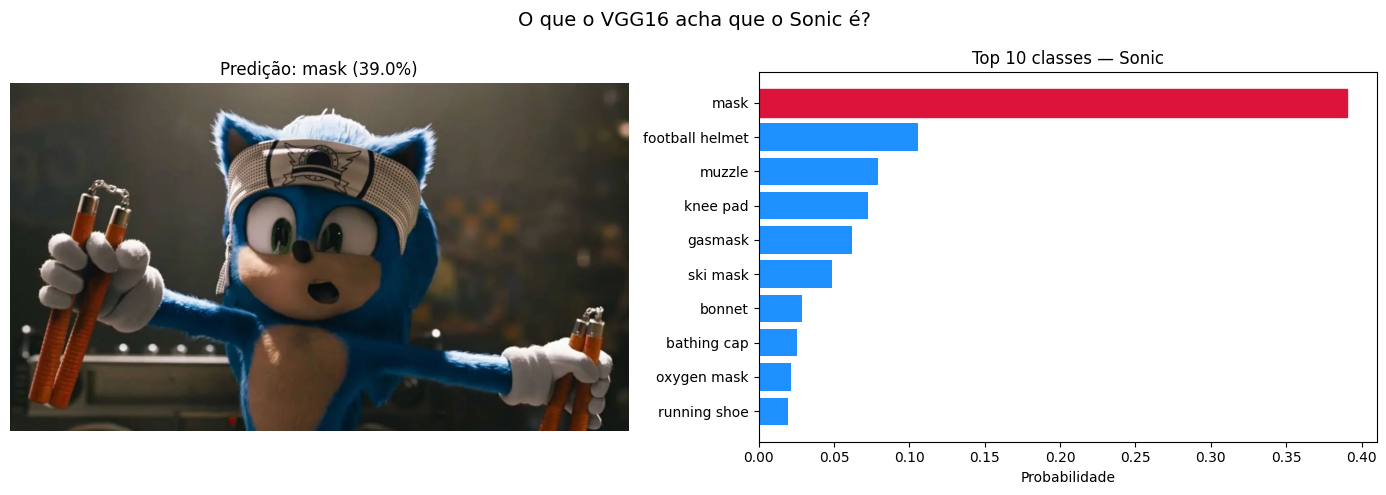

Predição do Sonic com VGG16: mask (Confiança: 39.05%)
Top 5 classes mais prováveis para o Sonic (VGG16):
  - mask: 39.05%
  - football helmet: 10.58%
  - muzzle: 7.92%
  - knee pad: 7.26%
  - gasmask: 6.17%


In [8]:
sonic = cv2.imread("/content/sonic.jpg")

# Mesma pipeline
sonic_tensor = preprocess(cv2.cvtColor(sonic, cv2.COLOR_BGR2RGB))
sonic_batch = sonic_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output_sonic = vgg_16_model(sonic_batch)

probs_sonic = torch.nn.functional.softmax(output_sonic[0], dim=0)
pred_sonic = imagenet_labels[torch.argmax(probs_sonic)]
pred_prob_sonic = probs_sonic[torch.argmax(probs_sonic)].item()

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(cv2.cvtColor(sonic, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Predição: {pred_sonic} ({pred_prob_sonic*100:.1f}%)")
axes[0].axis("off")

# Top 10 do Sonic
set_sonic = sorted(zip(imagenet_labels, probs_sonic.cpu().numpy()), key=lambda x: x[1])
labels_s, probs_s = zip(*set_sonic[-10:])
bars = axes[1].barh(labels_s, probs_s, color='dodgerblue')
bars[-1].set_color('crimson')
axes[1].set_xlabel("Probabilidade")
axes[1].set_title("Top 10 classes — Sonic")

plt.suptitle("O que o VGG16 acha que o Sonic é?", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Predição do Sonic com VGG16: {pred_sonic} (Confiança: {pred_prob_sonic*100:.2f}%)")
print("Top 5 classes mais prováveis para o Sonic (VGG16):")
for label, prob in reversed(list(zip(labels_s, probs_s))[-5:]):
    print(f"  - {label}: {prob*100:.2f}%")

> 📝 **Análise da predição do Sonic:** O VGG16 classificou o Sonic como **mask (máscara)** com 39.05% de confiança, seguido de **football helmet (capacete de futebol americano)** com 10.58%. Olhando para a imagem `sonic.jpg`, percebemos o motivo: ele está usando uma **faixa de cabeça branca (bandana/headband)** na testa e segurando **nunchakus**, caracterizado como um lutador de artes marciais/ninja! O modelo VGG16 confunde essa faixa branca na cabeça com uma máscara (`mask`), e os espinhos azuis com o formato redondo de um capacete (`football helmet`). A classe `muzzle` (focinho) em terceiro lugar também faz sentido pelo focinho saliente de animação com a boca aberta. Isso demonstra o limite de modelos que tentam classificar elementos fora de seu domínio de treino.



### 2. Trocar VGG16 por ResNet-18 (mais leve e moderna)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s] 


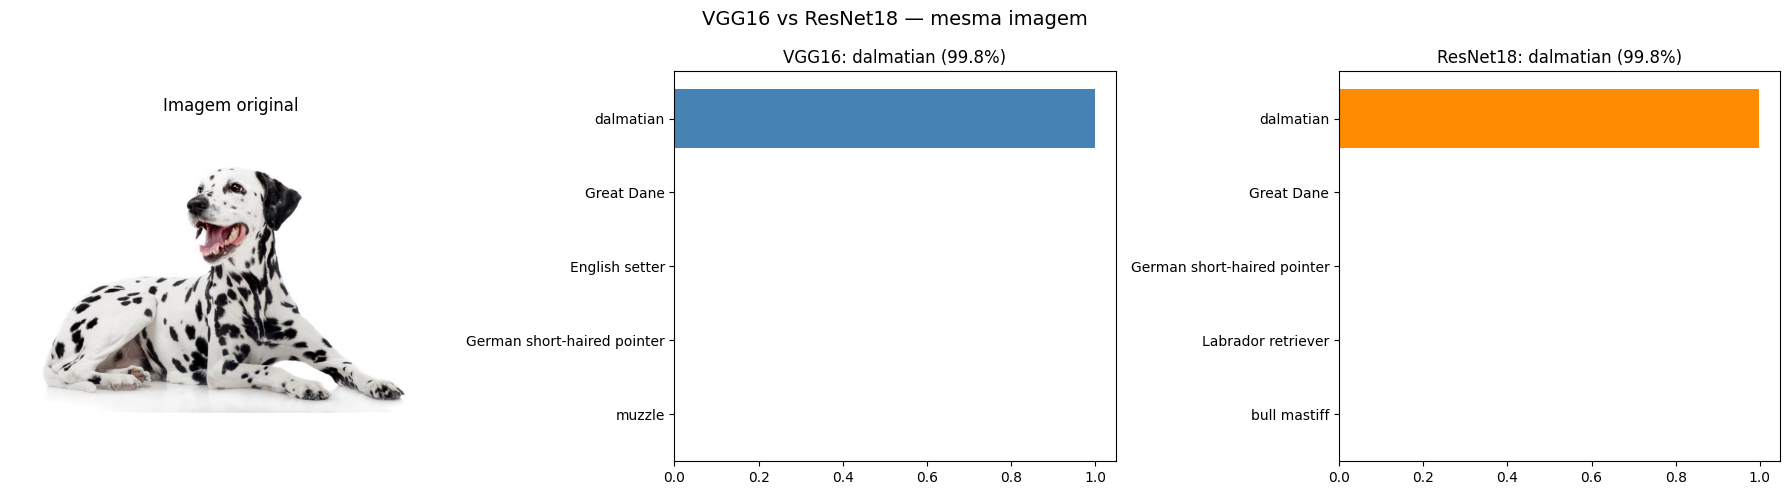

Predição do Dálmata com ResNet18: dalmatian (Confiança: 99.78%)
Top 5 classes mais prováveis (Dálmata - ResNet18):
  - dalmatian: 99.78%
  - Great Dane: 0.20%
  - German short-haired pointer: 0.01%
  - Labrador retriever: 0.00%
  - bull mastiff: 0.00%


In [9]:
# ResNet-18 — mais leve, com conexões residuais
weights_resnet = torchvision.models.ResNet18_Weights.DEFAULT
resnet_labels = weights_resnet.meta["categories"]
resnet_model = torchvision.models.resnet18(weights=weights_resnet).to(device)
resnet_model.eval()

preprocess_resnet = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Inferência no dog.jpeg com ResNet
dog_tensor = preprocess_resnet(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
dog_batch = dog_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    output_resnet = resnet_model(dog_batch)

probs_resnet = torch.nn.functional.softmax(output_resnet[0], dim=0)
pred_resnet = resnet_labels[torch.argmax(probs_resnet)]
pred_prob_resnet = probs_resnet[torch.argmax(probs_resnet)].item()

# Comparação VGG16 vs ResNet
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagem original")
axes[0].axis("off")

# VGG16 top 5
set_vgg = sorted(zip(imagenet_labels, probabilities.cpu().numpy()), key=lambda x: x[1])
l_v, p_v = zip(*set_vgg[-5:])
axes[1].barh(l_v, p_v, color='steelblue')
axes[1].set_title(f"VGG16: {pred_class} ({pred_prob*100:.1f}%)")

# ResNet top 5
set_res = sorted(zip(resnet_labels, probs_resnet.cpu().numpy()), key=lambda x: x[1])
l_r, p_r = zip(*set_res[-5:])
axes[2].barh(l_r, p_r, color='darkorange')
axes[2].set_title(f"ResNet18: {pred_resnet} ({pred_prob_resnet*100:.1f}%)")

plt.suptitle("VGG16 vs ResNet18 — mesma imagem", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Predição do Dálmata com ResNet18: {pred_resnet} (Confiança: {pred_prob_resnet*100:.2f}%)")
print("Top 5 classes mais prováveis (Dálmata - ResNet18):")
for label, prob in reversed(list(zip(l_r, p_r))[-5:]):
    print(f"  - {label}: {prob*100:.2f}%")

> 📝 **VGG16 vs ResNet18:**
> - **VGG16:** ~138M parâmetros, lenta mas sólida
> - **ResNet18:** ~11M parâmetros, muito mais leve, usa conexões residuais (skip connections)
> - Ambas foram treinadas na ImageNet e devem acertar o dálmata!

### 3. Explorar as categorias da ImageNet

In [10]:
print(f"Total de classes na ImageNet: {len(imagenet_labels)}\n")
print("Primeiras 20 classes:")
for i, label in enumerate(imagenet_labels[:20]):
    print(f"  {i}: {label}")

print(f"\n... e mais {len(imagenet_labels) - 20} classes!")

# Contar classes por "tema" (simplificado)
dogs = [l for l in imagenet_labels if 'terrier' in l.lower() or 'hound' in l.lower() or 'retriever' in l.lower() or 'spaniel' in l.lower() or 'poodle' in l.lower()]
print(f"\nExemplo: classes que parecem ser cachorros: {len(dogs)}")
print(f"Algumas: {dogs[:10]}")

Total de classes na ImageNet: 1000

Primeiras 20 classes:
  0: tench
  1: goldfish
  2: great white shark
  3: tiger shark
  4: hammerhead
  5: electric ray
  6: stingray
  7: cock
  8: hen
  9: ostrich
  10: brambling
  11: goldfinch
  12: house finch
  13: junco
  14: indigo bunting
  15: robin
  16: bulbul
  17: jay
  18: magpie
  19: chickadee

... e mais 980 classes!

Exemplo: classes que parecem ser cachorros: 45
Algumas: ['Japanese spaniel', 'Blenheim spaniel', 'toy terrier', 'Afghan hound', 'bloodhound', 'black-and-tan coonhound', 'Walker hound', 'English foxhound', 'Irish wolfhound', 'Italian greyhound']


> 📝 A ImageNet é **bem enviesada** pra raças de cachorro! Tem dezenas de classes de cães mas poucas de outros animais. Isso é um exemplo real de viés em datasets, que vimos na Aula 4.